# Diverse Initialisation: MCL1 MMGBSA

Tests whether a diversity-based initialisation (greedy MaxMin in embedding space)
helps overcome the early plateau observed with EI on MMGBSA scores.
Compares:
- **Diverse** init (centroid-seeded MaxMin) at sizes 1, 10, 50, 100
- **Random** init at sizes 1, 10, 50, 100, 600
- **EI baseline** (closest, size 1) from prior runs

All conditions use EI acquisition with a linear-empirical surrogate.
X-axis is **total molecules queried** (init + EI iterations) so budget is comparable across init sizes.

In [9]:
import sqlite3
from math import floor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': 16,
    "lines.linewidth": 2,
    "axes.labelsize": 18,
    "axes.titlesize": 22,
})

In [ ]:
RUNS_DIR = Path("../bayesian_optimization_results")
DATA_PATH = Path("../bayesian_optimization/data/processed/MCL1-mmgbsa.csv")
K_RATIO = 0.01

DIVERSE_SIZES = [10, 50, 100]
RANDOM_SIZES  = [1, 10, 50, 100]

# EI baseline: closest init, size 1, produced by run_bayesian_optimization.sh
EI_DB = Path("results/mcl1_mmpbsa_gb_proto_shuffled.sqlite")

In [11]:
def load_db(db_path: Path) -> pd.DataFrame:
    """Load query results joined with experiment metadata."""
    con = sqlite3.connect(db_path)
    df = pd.read_sql(
        "SELECT * FROM query_result JOIN experiment ON query_result.experiment_id == experiment.id",
        con,
    )
    con.close()
    return df


def add_query_index(df: pd.DataFrame) -> pd.DataFrame:
    """Assign a per-experiment sequential query index ordered by iteration.

    Initialisation rows (iteration == -1) come first, so the index reflects
    true budget consumption: init molecules are counted before EI begins.
    """
    df = df.sort_values(["experiment_id", "iteration"])
    df["molecules_queried"] = df.groupby("experiment_id").cumcount() + 1
    return df


def prepare(df: pd.DataFrame, source: pd.DataFrame, k: int) -> pd.DataFrame:
    """Add derived columns: top-k flag, cumulative top-k count, display labels."""
    df = add_query_index(df)

    df["Embedding Model"] = df["embedding_model"].replace({
        "fingerprint":       "Morgan Fingerprint",
        "chemberta-mtr":     "ChemBERTa-2",
        "molformer":         "MolFormer",
    })

    top_k_smiles = set(source.nsmallest(k, "target")["smiles"])
    df["is_top_k"] = df["molecule"].isin(top_k_smiles)
    df["is_top_k_cum"] = (
        df.sort_values(["experiment_id", "molecules_queried"])
        .groupby("experiment_id")["is_top_k"]
        .cumsum()
    )
    return df

In [12]:
source = pd.read_csv(DATA_PATH)
k = int(floor(len(source) * K_RATIO))
print(f"Top-{K_RATIO*100:.0f}% threshold: {k} molecules out of {len(source)}")

Top-1% threshold: 593 molecules out of 59356


In [13]:
dfs = []

# Diverse init
for size in DIVERSE_SIZES:
    db = RUNS_DIR / f"mcl1_mmgbsa_ei_diverse_init{size}.sqlite"
    if not db.exists():
        print(f"Missing: {db}")
        continue
    df = load_db(db)
    df = prepare(df, source, k)
    df["Init"] = "Diverse"
    df["Init Size"] = size
    df["Label"] = f"Diverse (n={size})"
    dfs.append(df)

# EI baseline: closest init, size 1
if EI_DB.exists():
    df_ei = load_db(EI_DB)
    df_ei = prepare(df_ei, source, k)
    df_ei = df_ei[df_ei["surrogate"] == "linear-empirical"]
    df_ei["Init"] = "Closest"
    df_ei["Init Size"] = 1
    df_ei["Label"] = "Centroid (n=1)"
    dfs.append(df_ei)
else:
    print(f"EI baseline not found: {EI_DB}")

data = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(data['experiment_id'].unique())} experiments, {len(data)} rows")
data[["Label", "Init", "Init Size", "Embedding Model"]].drop_duplicates().sort_values(["Init", "Init Size"])

Loaded 6 experiments, 43683 rows


,Label,Init,Init Size,Embedding Model
32880,Centroid (n=1),Closest,1,MolFormer
36481,Centroid (n=1),Closest,1,Morgan Fingerprint
40082,Centroid (n=1),Closest,1,ChemBERTa-2
0,Diverse (n=10),Diverse,10,ChemBERTa-2
3610,Diverse (n=10),Diverse,10,Morgan Fingerprint
7220,Diverse (n=10),Diverse,10,MolFormer
10830,Diverse (n=50),Diverse,50,MolFormer
14480,Diverse (n=50),Diverse,50,Morgan Fingerprint
18130,Diverse (n=50),Diverse,50,ChemBERTa-2
21780,Diverse (n=100),Diverse,100,Morgan Fingerprint


## Top-1% Retrieval Curves

Each panel is one embedding model. X-axis is total molecules queried (init + EI), so
conditions with a larger init budget are not artificially favoured by ignoring their init cost.

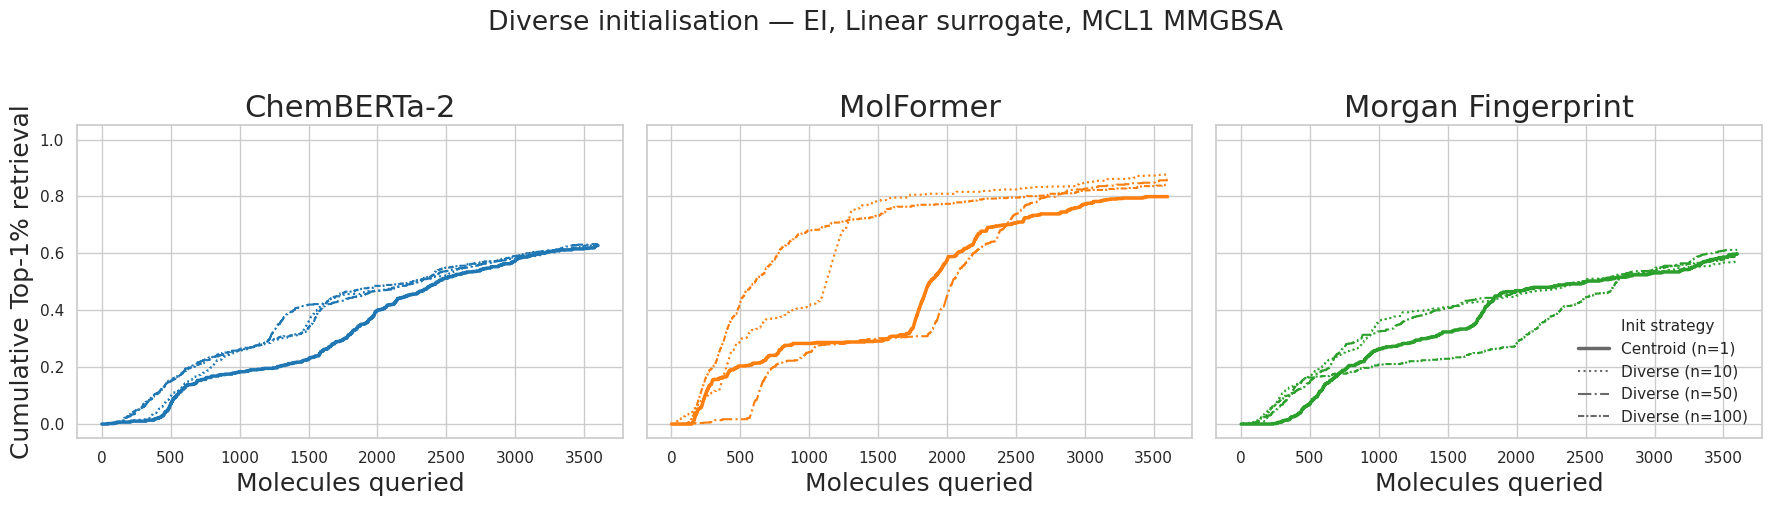

In [46]:
import matplotlib.lines as mlines

_palette = sns.color_palette("tab20")
COLORS = {
    "ChemBERTa-2":        _palette[0],
    "MolFormer":          _palette[2],
    "Morgan Fingerprint": _palette[4],
}

size_style = {1: "-", 10: ":", 50: "-.", 100: (0, (3, 1, 1, 1))}
size_lw    = {1: 2.5,  10: 1.5, 50: 1.5, 100: 1.5}

diverse_labels  = [f"Diverse (n={s})" for s in DIVERSE_SIZES]
baseline_labels = ["Centroid (n=1)"]
labels_order    = baseline_labels + diverse_labels

embedding_order = ["ChemBERTa-2", "MolFormer", "Morgan Fingerprint"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, embedding in zip(axes, embedding_order):
    color  = COLORS[embedding]
    subset = data[data["Embedding Model"] == embedding]

    for label in labels_order:
        group = subset[subset["Label"] == label]
        if group.empty:
            continue
        curve = (
            group.groupby("molecules_queried")["is_top_k_cum"].max() / k
        )
        init_size = group["Init Size"].iloc[0]
        curve = curve[(curve.index >= init_size) & (curve.index <= 3600)]

        ax.plot(curve.index, curve.values, label=label,
                color=color, linestyle=size_style[init_size],
                linewidth=size_lw[init_size])

    ax.set_title(embedding)
    ax.set_xlabel("Molecules queried")
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel(f"Cumulative Top-{K_RATIO*100:.0f}% retrieval")

legend_elements = [mlines.Line2D([0], [0], color="none", label="Init strategy")]
for label, size in zip(labels_order, [1] + DIVERSE_SIZES):
    legend_elements.append(
        mlines.Line2D([0], [0], color="dimgray",
                      linestyle=size_style[size], linewidth=size_lw[size],
                      label=label)
    )
axes[-1].legend(handles=legend_elements, loc="lower right", frameon=False)

fig.suptitle("Diverse initialisation — EI, Linear surrogate, MCL1 MMGBSA", y=1.02)
plt.tight_layout()
plt.savefig("figures/diverse_init_retrieval.pdf", dpi=300, bbox_inches="tight")
plt.savefig("figures/diverse_init_retrieval.svg", dpi=300, bbox_inches="tight")
plt.show()


## Final Retrieval Rate (Summary Table)

Fraction of top-1% molecules found across the full run.

In [15]:
final = (
    data.groupby(["experiment_id", "Label", "Embedding Model"])["is_top_k"]
    .sum()
    .div(k)
    .reset_index()
    .rename(columns={"is_top_k": "Retrieval Rate"})
    .groupby(["Label", "Embedding Model"])["Retrieval Rate"]
    .mean()
    .unstack("Embedding Model")
    .reindex(labels_order)
    [embedding_order]
    .round(3)
)
final

Embedding Model,ChemBERTa-2,MolFormer,Morgan Fingerprint
Label,,,
"EI baseline (centroid, n=1)",NaN,NaN,NaN
Diverse (n=10),0.621,0.877,0.572
Diverse (n=50),0.634,0.860,0.612
Diverse (n=100),0.639,0.845,0.597
Random (n=1),NaN,NaN,NaN
Random (n=10),NaN,NaN,NaN
Random (n=50),NaN,NaN,NaN
Random (n=100),NaN,NaN,NaN


## Early-Phase Retrieval

Cumulative top-1% found after the first 600 molecules queried — equal to the largest random init
size. This isolates whether a larger diverse init gives a head-start that persists.

In [16]:
EARLY_CUTOFF = 600

early = (
    data[data["molecules_queried"] <= EARLY_CUTOFF]
    .groupby(["experiment_id", "Label", "Embedding Model"])["is_top_k"]
    .sum()
    .div(k)
    .reset_index()
    .rename(columns={"is_top_k": f"Retrieval Rate (≤{EARLY_CUTOFF} queries)"})
    .groupby(["Label", "Embedding Model"])[f"Retrieval Rate (≤{EARLY_CUTOFF} queries)"]
    .mean()
    .unstack("Embedding Model")
    .reindex(labels_order)
    [embedding_order]
    .round(3)
)
early

Embedding Model,ChemBERTa-2,MolFormer,Morgan Fingerprint
Label,,,
"EI baseline (centroid, n=1)",NaN,NaN,NaN
Diverse (n=10),0.140,0.331,0.204
Diverse (n=50),0.187,0.073,0.189
Diverse (n=100),0.185,0.496,0.169
Random (n=1),NaN,NaN,NaN
Random (n=10),NaN,NaN,NaN
Random (n=50),NaN,NaN,NaN
Random (n=100),NaN,NaN,NaN
